**Question 1**

In [ ]:
%pip install pygad


   -------------------- ------------------- 1/2 [pygad]
   -------------------- ------------------- 1/2 [pygad]
   -------------------- ------------------- 1/2 [pygad]
   -------------------- ------------------- 1/2 [pygad]
   -------------------- ------------------- 1/2 [pygad]
   -------------------- ------------------- 1/2 [pygad]
   ---------------------------------------- 2/2 [pygad]

Note: you may need to restart the kernel to use updated packages.


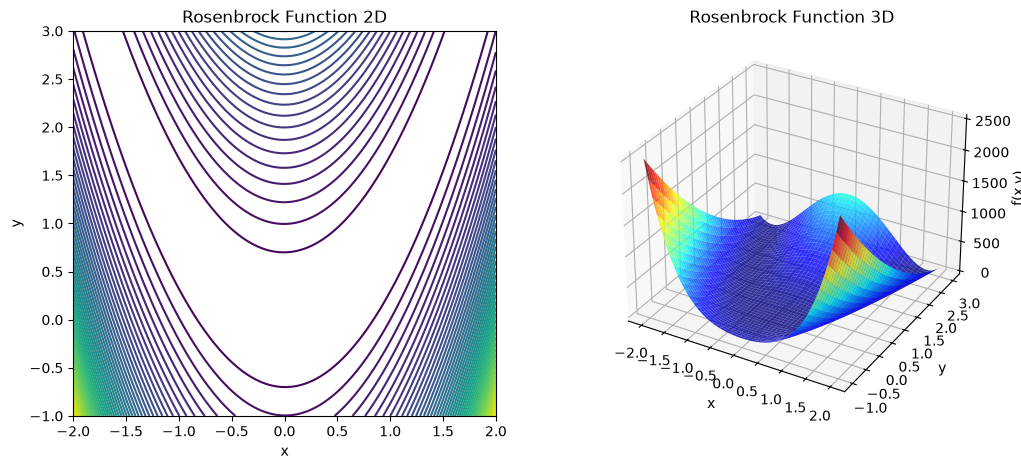

Initial guess [-1.9, 1.9], Result: [0.99999538 0.99999075], Value: 2.1366834694459856e-11, Success: True, Iterations: 33, Time: 0.0357 sec
Initial guess [3, 3], Result: [0.99999636 0.99999282], Value: 1.4129451308524594e-11, Success: False, Iterations: 43, Time: 0.0955 sec
Initial guess [1, 2], Result: [0.99999649 0.99999304], Value: 1.2746936393572941e-11, Success: False, Iterations: 21, Time: 0.0654 sec
Initial guess [1, 1], Result: [1. 1.], Value: 0.0, Success: True, Iterations: 0, Time: 0.0007 sec


c:\Users\Admin\miniconda3\envs\mude-base\Lib\site-packages\pygad\utils\validation.py:966: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(


PyGAD initial guess [-1.9, 1.9], Solution: [1.0022738  1.00444813], Value: 6.2650455633870275e-06, Iterations: 2000, Time: 3.0026 sec
PyGAD initial guess [3, 3], Solution: [1.01138616 1.02195081], Value: 0.00022011216327500014, Iterations: 2000, Time: 3.2009 sec
PyGAD initial guess [1, 2], Solution: [1.02169976 1.04394739], Value: 0.0004714723916227487, Iterations: 2000, Time: 2.5169 sec
PyGAD initial guess [1, 1], Solution: [1. 1.], Value: 0.0, Iterations: 2000, Time: 3.2503 sec


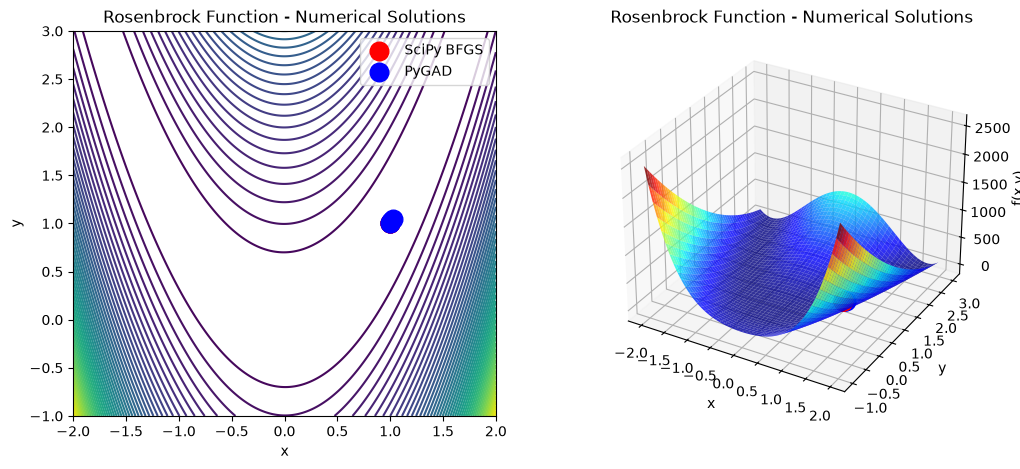

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

# Rosenbrock
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock([X, Y])

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Rosenbrock Function 2D")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Rosenbrock Function 3D")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("f(x,y)")

plt.show()


# =========================
# SCIPY BFGS
# =========================

elapsed_time = []

init_guesses = [
    [-1.9, 1.9],
    [3, 3],
    [1, 2],
    [1, 1]
]

scipy_solutions = []

for guess in init_guesses:

    start_time = time.perf_counter()

    result = minimize(
        rosenbrock,
        guess,
        method='BFGS'
    )

    end_time = time.perf_counter()

    elapsed_time = end_time - start_time

    scipy_solutions.append(result.x.copy())

    print(
        f"Initial guess {guess}, "
        f"Result: {result.x}, "
        f"Value: {result.fun}, "
        f"Success: {result.success}, "
        f"Iterations: {result.nit}, "
        f"Time: {elapsed_time:.4f} sec"
    )


# =========================
# PYGAD GENETIC ALGORITHM
# =========================

def fitness_func(ga_instance, solution, solution_idx):
    return -rosenbrock(solution)


pygad_solutions = []

for guess in init_guesses:

    # Create 19 random individuals
    initial_population = np.random.uniform(
        low=-2,
        high=2,
        size=(19, 2)
    )

    # Add the specified initial guess
    # Total population = 20
    initial_population = np.vstack([
        guess,
        initial_population
    ])

    start_time = time.perf_counter()

    ga_instance = pygad.GA(
        num_generations=2000,
        sol_per_pop=20,
        num_genes=2,
        num_parents_mating=8,
        fitness_func=fitness_func,
        initial_population=initial_population,
        gene_space={'low': -2, 'high': 2}
    )

    ga_instance.run()

    solution, solution_fitness, _ = ga_instance.best_solution()

    end_time = time.perf_counter()

    elapsed_time = end_time - start_time

    pygad_solutions.append(solution.copy())

    print(
        f"PyGAD initial guess {guess}, "
        f"Solution: {solution}, "
        f"Value: {rosenbrock(solution)}, "
        f"Iterations: {ga_instance.generations_completed}, "
        f"Time: {elapsed_time:.4f} sec"
    )


# =========================
# PLOT NUMERICAL SOLUTIONS
# =========================

fig = plt.figure(figsize=(12,5))


# -------------------------
# 2D PLOT
# -------------------------

ax1 = fig.add_subplot(121)

cp = ax1.contour(
    X,
    Y,
    Z,
    levels=50
)

# SciPy solutions
scipy_solutions_array = np.array(scipy_solutions)

ax1.scatter(
    scipy_solutions_array[:, 0],
    scipy_solutions_array[:, 1],
    color='red',
    s=180,
    marker='o',
    label='SciPy BFGS'
)


# PyGAD solutions
pygad_solutions_array = np.array(pygad_solutions)

ax1.scatter(
    pygad_solutions_array[:, 0],
    pygad_solutions_array[:, 1],
    color='blue',
    s=180,
    marker='o',
    label='PyGAD'
)

ax1.set_title("Rosenbrock Function - Numerical Solutions")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend()


# -------------------------
# 3D PLOT
# -------------------------

ax2 = fig.add_subplot(122, projection='3d')

ax2.plot_surface(
    X,
    Y,
    Z,
    cmap='jet',
    alpha=0.8
)


# SciPy solutions
for sol in scipy_solutions:

    x_sol = sol[0]
    y_sol = sol[1]
    z_sol = rosenbrock(sol)

    ax2.scatter(
        x_sol,
        y_sol,
        z_sol,
        color='red',
        s=180,
        marker='o'
    )


# PyGAD solutions
for sol in pygad_solutions:

    x_sol = sol[0]
    y_sol = sol[1]
    z_sol = rosenbrock(sol)

    ax2.scatter(
        x_sol,
        y_sol,
        z_sol,
        color='blue',
        s=180,
        marker='o'
    )


ax2.set_title("Rosenbrock Function - Numerical Solutions")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("f(x,y)")

plt.show()

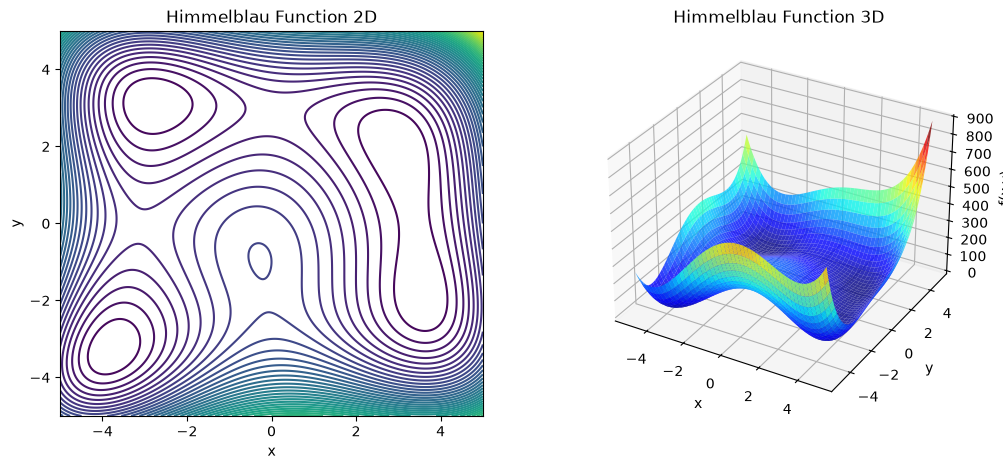

Initial guess [0, 0], Result: [2.99999994 1.99999999], Value: 1.3782273267389757e-13, Success: True, Iterations: 10, Time: 0.0106 sec
Initial guess [-4, 4], Result: [-2.80511803  3.13131251], Value: 1.0206446176713682e-13, Success: True, Iterations: 10, Time: 0.0070 sec
Initial guess [4, 0], Result: [ 3.58442834 -1.84812653], Value: 2.263853503678799e-16, Success: True, Iterations: 8, Time: 0.0063 sec
Initial guess [0, 4], Result: [-2.80511809  3.13131251], Value: 3.006311544276386e-15, Success: True, Iterations: 7, Time: 0.0047 sec
Initial guess [-4, 0], Result: [-3.77931026 -3.283186  ], Value: 8.372997926448171e-15, Success: True, Iterations: 10, Time: 0.0126 sec
Initial guess [4, 4], Result: [3.00000001 2.        ], Value: 5.246128523579971e-15, Success: True, Iterations: 13, Time: 0.0131 sec
PyGAD initial guess [0, 0], Solution: [3.00021715 2.00902102], Value: 0.0014302790897271905, Iterations: 300, Time: 0.6605 sec
PyGAD initial guess [-4, 4], Solution: [ 3.58768814 -1.85797278],

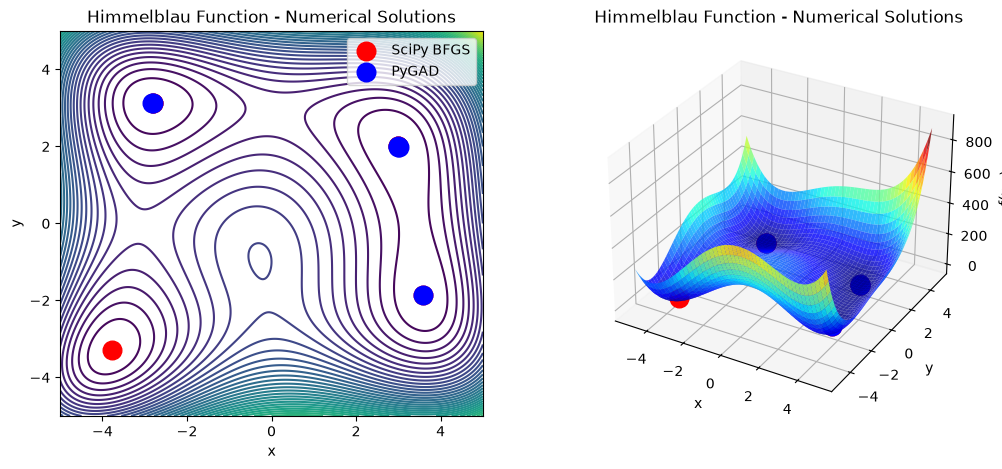

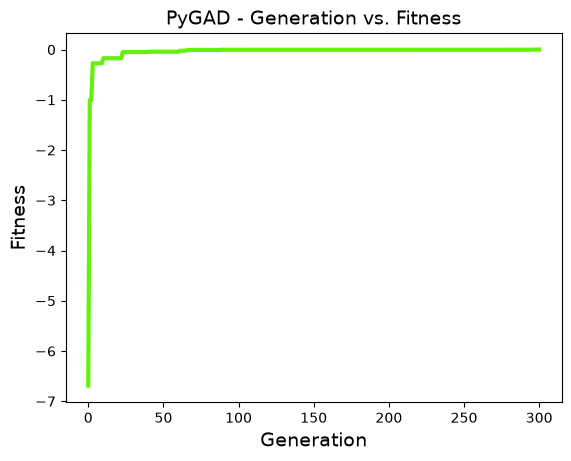

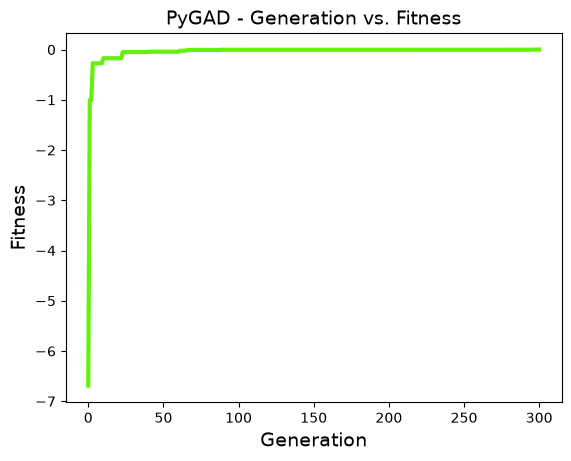

In [2]:
# Himmelblau Function
def himmelblau(x):
    x = np.asarray(x)

    return (
        (x[0]**2 + x[1] - 11)**2
        +
        (x[0] + x[1]**2 - 7)**2
    )


x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)

X, Y = np.meshgrid(x_range, y_range)
Z = himmelblau([X, Y])


# =========================
# 2D AND 3D PLOT
# =========================

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(121)

cp = ax1.contour(
    X,
    Y,
    Z,
    levels=50
)

ax1.set_title("Himmelblau Function 2D")
ax1.set_xlabel("x")
ax1.set_ylabel("y")


ax2 = fig.add_subplot(122, projection='3d')

ax2.plot_surface(
    X,
    Y,
    Z,
    cmap='jet',
    alpha=0.8
)

ax2.set_title("Himmelblau Function 3D")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("f(x,y)")

plt.show()


# =========================
# SCIPY BFGS
# =========================

init_guesses = [
    [0, 0],
    [-4, 4],
    [4, 0],
    [0, 4],
    [-4, 0],
    [4, 4]
]

scipy_solutions = []

for guess in init_guesses:

    start_time = time.perf_counter()

    result = minimize(
        himmelblau,
        guess,
        method='BFGS'
    )

    end_time = time.perf_counter()

    elapsed_time = end_time - start_time

    scipy_solutions.append(result.x.copy())

    print(
        f"Initial guess {guess}, "
        f"Result: {result.x}, "
        f"Value: {result.fun}, "
        f"Success: {result.success}, "
        f"Iterations: {result.nit}, "
        f"Time: {elapsed_time:.4f} sec"
    )


# =========================
# PYGAD GENETIC ALGORITHM
# =========================

def fitness_func2(ga_instance, solution, solution_idx):
    return -himmelblau(solution)


pygad_solutions = []

for guess in init_guesses:

    # Create 29 random individuals
    initial_population = np.random.uniform(
        low=-5,
        high=5,
        size=(29, 2)
    )

    # Add the specified initial guess
    # Total population = 30
    initial_population = np.vstack([
        guess,
        initial_population
    ])

    start_time = time.perf_counter()

    ga_instance = pygad.GA(
        num_generations=300,
        sol_per_pop=30,
        num_genes=2,
        num_parents_mating=12,
        fitness_func=fitness_func2,
        initial_population=initial_population,
        gene_space={'low': -5, 'high': 5}
    )

    ga_instance.run()

    solution, solution_fitness, _ = ga_instance.best_solution()

    end_time = time.perf_counter()

    elapsed_time = end_time - start_time

    pygad_solutions.append(solution.copy())

    print(
        f"PyGAD initial guess {guess}, "
        f"Solution: {solution}, "
        f"Value: {himmelblau(solution)}, "
        f"Iterations: {ga_instance.generations_completed}, "
        f"Time: {elapsed_time:.4f} sec"
    )


# =========================
# PLOT NUMERICAL SOLUTIONS
# =========================

fig = plt.figure(figsize=(12,5))


# -------------------------
# 2D PLOT
# -------------------------

ax1 = fig.add_subplot(121)

cp = ax1.contour(
    X,
    Y,
    Z,
    levels=50
)


scipy_solutions_array = np.array(scipy_solutions)

ax1.scatter(
    scipy_solutions_array[:, 0],
    scipy_solutions_array[:, 1],
    color='red',
    s=180,
    marker='o',
    label='SciPy BFGS'
)


pygad_solutions_array = np.array(pygad_solutions)

ax1.scatter(
    pygad_solutions_array[:, 0],
    pygad_solutions_array[:, 1],
    color='blue',
    s=180,
    marker='o',
    label='PyGAD'
)

ax1.set_title("Himmelblau Function - Numerical Solutions")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend()


# -------------------------
# 3D PLOT
# -------------------------

ax2 = fig.add_subplot(122, projection='3d')

ax2.plot_surface(
    X,
    Y,
    Z,
    cmap='jet',
    alpha=0.8
)


# SciPy solutions
for sol in scipy_solutions:

    x_sol = sol[0]
    y_sol = sol[1]
    z_sol = himmelblau(sol)

    ax2.scatter(
        x_sol,
        y_sol,
        z_sol,
        color='red',
        s=180,
        marker='o'
    )


# PyGAD solutions
for sol in pygad_solutions:

    x_sol = sol[0]
    y_sol = sol[1]
    z_sol = himmelblau(sol)

    ax2.scatter(
        x_sol,
        y_sol,
        z_sol,
        color='blue',
        s=180,
        marker='o'
    )


ax2.set_title("Himmelblau Function - Numerical Solutions")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("f(x,y)")

plt.show()


# =========================
# PYGAD FITNESS PLOT
# =========================

ga_instance.plot_fitness()

**Question 2**  

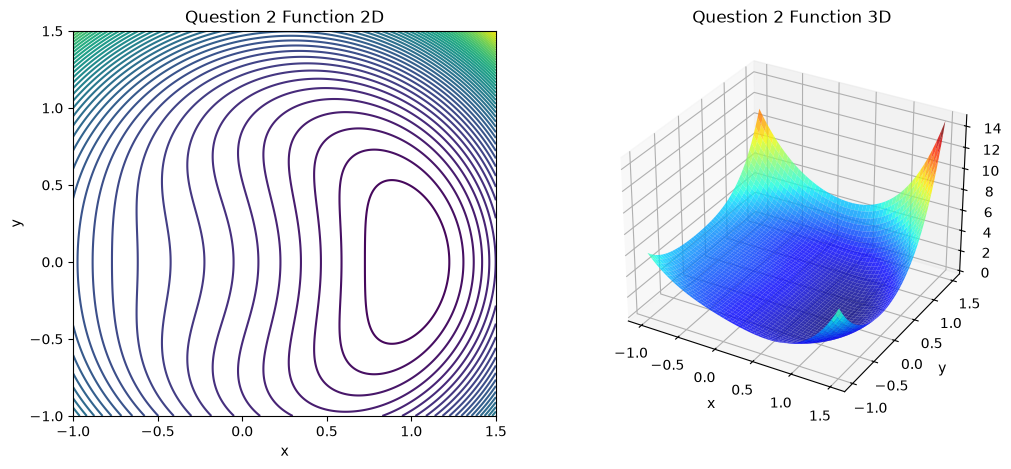

Initial guess [0, 0], Result: [ 9.99999966e-01 -1.64047755e-08], Value: 5.950412924404877e-15, Success: True, Iterations: 3, Time: 0.0053 sec
Initial guess [-1, 1], Result: [ 9.99999962e-01 -4.52151057e-08], Value: 9.356036734008036e-15, Success: True, Iterations: 11, Time: 0.0158 sec
Initial guess [1, 0], Result: [1. 0.], Value: 0.0, Success: True, Iterations: 0, Time: 0.0007 sec
Initial guess [0, 1], Result: [ 9.99999990e-01 -5.87222017e-10], Value: 4.568146479040473e-16, Success: True, Iterations: 8, Time: 0.0106 sec
Initial guess [-1, 0], Result: [9.99999993e-01 1.52074622e-08], Value: 4.608519895500347e-16, Success: True, Iterations: 5, Time: 0.0039 sec
Initial guess [1, 1], Result: [ 9.99999994e-01 -2.63536186e-09], Value: 2.0251206464610833e-16, Success: True, Iterations: 10, Time: 0.0145 sec
PyGAD initial guess [0, 0], Solution: [1.00583504 0.00455102], Value: 0.00019223159064969553, Iterations: 300, Time: 0.8540 sec
PyGAD initial guess [-1, 1], Solution: [ 1.00365631e+00 -1.86

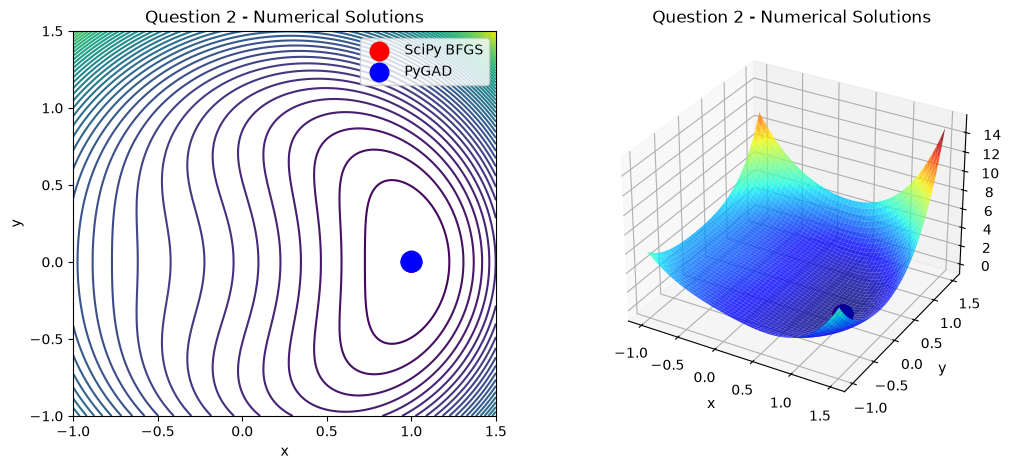

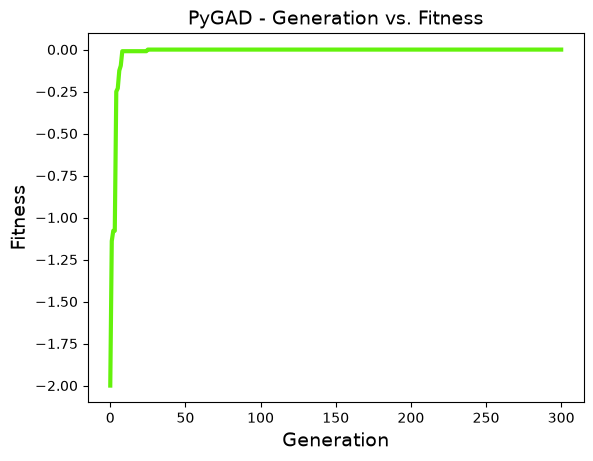

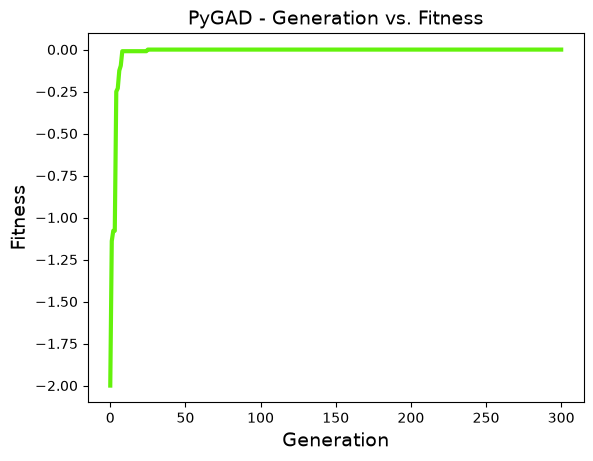

In [3]:
# Question 2 Function
def question2(x):
    x = np.asarray(x)

    return (
        (x[0]**2 + x[1]**2 - 1)**2
        +
        (x[0] - 1)**2
        +
        x[1]**2
    )


x_range = np.linspace(-1, 1.5, 400)
y_range = np.linspace(-1, 1.5, 400)

X, Y = np.meshgrid(x_range, y_range)
Z = question2([X, Y])


# =========================
# 2D AND 3D PLOT
# =========================

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(121)

cp = ax1.contour(
    X,
    Y,
    Z,
    levels=50
)

ax1.set_title("Question 2 Function 2D")
ax1.set_xlabel("x")
ax1.set_ylabel("y")


ax2 = fig.add_subplot(122, projection='3d')

ax2.plot_surface(
    X,
    Y,
    Z,
    cmap='jet',
    alpha=0.8
)

ax2.set_title("Question 2 Function 3D")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("f(x,y)")

plt.show()


# =========================
# SCIPY BFGS
# =========================

init_guesses = [
    [0, 0],
    [-1, 1],
    [1, 0],
    [0, 1],
    [-1, 0],
    [1, 1]
]

scipy_solutions = []

for guess in init_guesses:

    start_time = time.perf_counter()

    result = minimize(
        question2,
        guess,
        method='BFGS'
    )

    end_time = time.perf_counter()

    elapsed_time = end_time - start_time

    scipy_solutions.append(result.x.copy())

    print(
        f"Initial guess {guess}, "
        f"Result: {result.x}, "
        f"Value: {result.fun}, "
        f"Success: {result.success}, "
        f"Iterations: {result.nit}, "
        f"Time: {elapsed_time:.4f} sec"
    )


# =========================
# PYGAD GENETIC ALGORITHM
# =========================

def fitness_func2(ga_instance, solution, solution_idx):
    return -question2(solution)


pygad_solutions = []

for guess in init_guesses:

    # Create 29 random individuals
    initial_population = np.random.uniform(
        low=-5,
        high=5,
        size=(29, 2)
    )

    # Add the specified initial guess
    # Total population = 30
    initial_population = np.vstack([
        guess,
        initial_population
    ])

    start_time = time.perf_counter()

    ga_instance = pygad.GA(
        num_generations=300,
        sol_per_pop=30,
        num_genes=2,
        num_parents_mating=12,
        fitness_func=fitness_func2,
        initial_population=initial_population,
        gene_space={'low': -5, 'high': 5}
    )

    ga_instance.run()

    solution, solution_fitness, _ = ga_instance.best_solution()

    end_time = time.perf_counter()

    elapsed_time = end_time - start_time

    pygad_solutions.append(solution.copy())

    print(
        f"PyGAD initial guess {guess}, "
        f"Solution: {solution}, "
        f"Value: {question2(solution)}, "
        f"Iterations: {ga_instance.generations_completed}, "
        f"Time: {elapsed_time:.4f} sec"
    )


# =========================
# PLOT NUMERICAL SOLUTIONS
# =========================

fig = plt.figure(figsize=(12,5))


# -------------------------
# 2D PLOT
# -------------------------

ax1 = fig.add_subplot(121)

cp = ax1.contour(
    X,
    Y,
    Z,
    levels=50
)


scipy_solutions_array = np.array(scipy_solutions)

ax1.scatter(
    scipy_solutions_array[:, 0],
    scipy_solutions_array[:, 1],
    color='red',
    s=180,
    marker='o',
    label='SciPy BFGS'
)


pygad_solutions_array = np.array(pygad_solutions)

ax1.scatter(
    pygad_solutions_array[:, 0],
    pygad_solutions_array[:, 1],
    color='blue',
    s=180,
    marker='o',
    label='PyGAD'
)

ax1.set_title("Question 2 - Numerical Solutions")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend()


# -------------------------
# 3D PLOT
# -------------------------

ax2 = fig.add_subplot(122, projection='3d')

ax2.plot_surface(
    X,
    Y,
    Z,
    cmap='jet',
    alpha=0.8
)


# SciPy solutions
for sol in scipy_solutions:

    x_sol = sol[0]
    y_sol = sol[1]
    z_sol = question2(sol)

    ax2.scatter(
        x_sol,
        y_sol,
        z_sol,
        color='red',
        s=180,
        marker='o'
    )


# PyGAD solutions
for sol in pygad_solutions:

    x_sol = sol[0]
    y_sol = sol[1]
    z_sol = question2(sol)

    ax2.scatter(
        x_sol,
        y_sol,
        z_sol,
        color='blue',
        s=180,
        marker='o'
    )


ax2.set_title("Question 2 - Numerical Solutions")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("f(x,y)")

plt.show()


# =========================
# PYGAD FITNESS PLOT
# =========================

ga_instance.plot_fitness()